# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

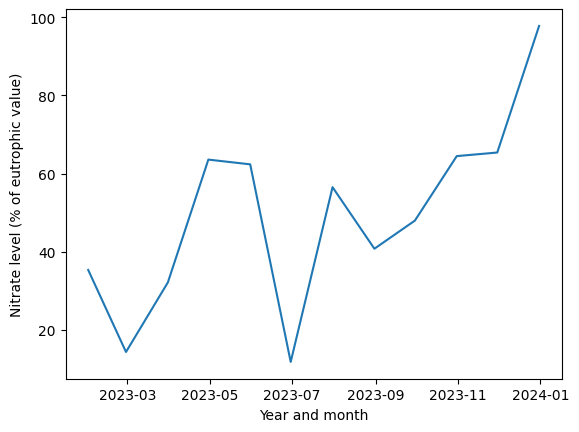

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

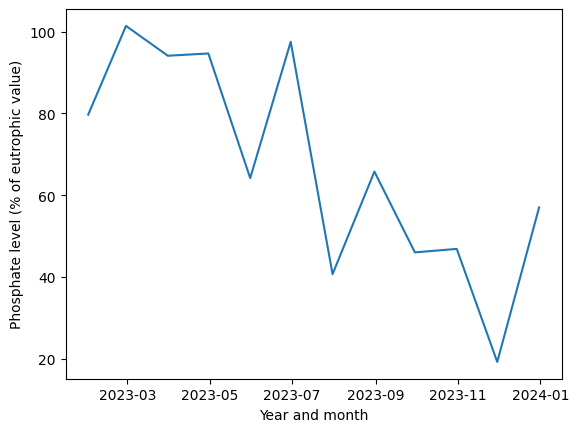

In [3]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

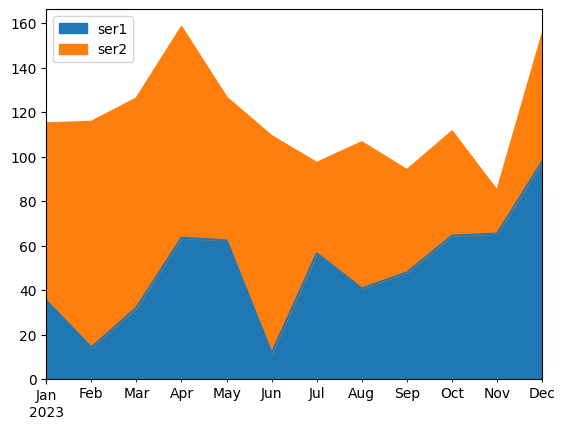

In [4]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

An area plot makes it easy to see the overall combined level of nitrate and phosphate over time, since the stacked areas show the total amount of nutrients in the water sample. This can help highlight periods where the overall nutrient level is higher. However, a downside is that it becomes harder to compare the individual nitrate and phosphate levels directly because the second series is stacked on top of the first one. The separate line graphs make it easier to see the trend for each chemical on its own, like how nitrate generally increases over the year while phosphate fluctuates and decreases. To improve the graphs, I would label the two series clearly as nitrate and phosphate instead of using generic names, add a legend, and include a title so it’s clearer what the graphs are showing.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

### Chronic Kidney Disease Dataset

In [5]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
chronic_kidney_disease = fetch_ucirepo(id=336)

# features and target
X = chronic_kidney_disease.data.features
y = chronic_kidney_disease.data.targets

# combine into one dataframe
import pandas as pd
df = pd.concat([X, y], axis=1)

In [6]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df.nunique()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    str    
 6   pc      335 non-null    str    
 7   pcc     396 non-null    str    
 8   ba      396 non-null    str    
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     398 non-null    str    
 19  dm      398 non-null    str    
 20  cad     398 non-null    str    
 21  appet   399 non-null    str    
 22  pe      399 n

age       76
bp        10
sg         5
al         6
su         6
rbc        2
pc         2
pcc        2
ba         2
bgr      146
bu       118
sc        84
sod       34
pot       40
hemo     115
pcv       42
wbcc      89
rbcc      45
htn        2
dm         3
cad        2
appet      2
pe         2
ane        2
class      3
dtype: int64

In [7]:
df[['age','bp','bgr','sc','hemo']].corr()

,age,bp,bgr,sc,hemo
age,1.000000,0.159480,0.244992,0.132531,-0.192928
bp,0.159480,1.000000,0.160193,0.146222,-0.306540
bgr,0.244992,0.160193,1.000000,0.114875,-0.306189
sc,0.132531,0.146222,0.114875,1.000000,-0.401670
hemo,-0.192928,-0.306540,-0.306189,-0.401670,1.000000


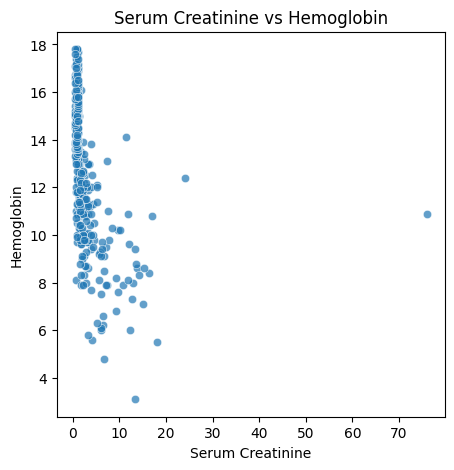

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

sns.scatterplot(data=df, x="sc", y="hemo", alpha=0.7)

plt.title("Serum Creatinine vs Hemoglobin")
plt.xlabel("Serum Creatinine")
plt.ylabel("Hemoglobin")

plt.show()

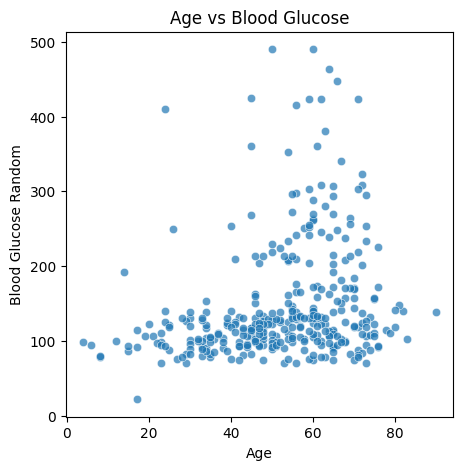

In [9]:
plt.figure(figsize=(5,5))

sns.scatterplot(data=df, x="age", y="bgr", alpha=0.7)

plt.title("Age vs Blood Glucose")
plt.xlabel("Age")
plt.ylabel("Blood Glucose Random")

plt.show()

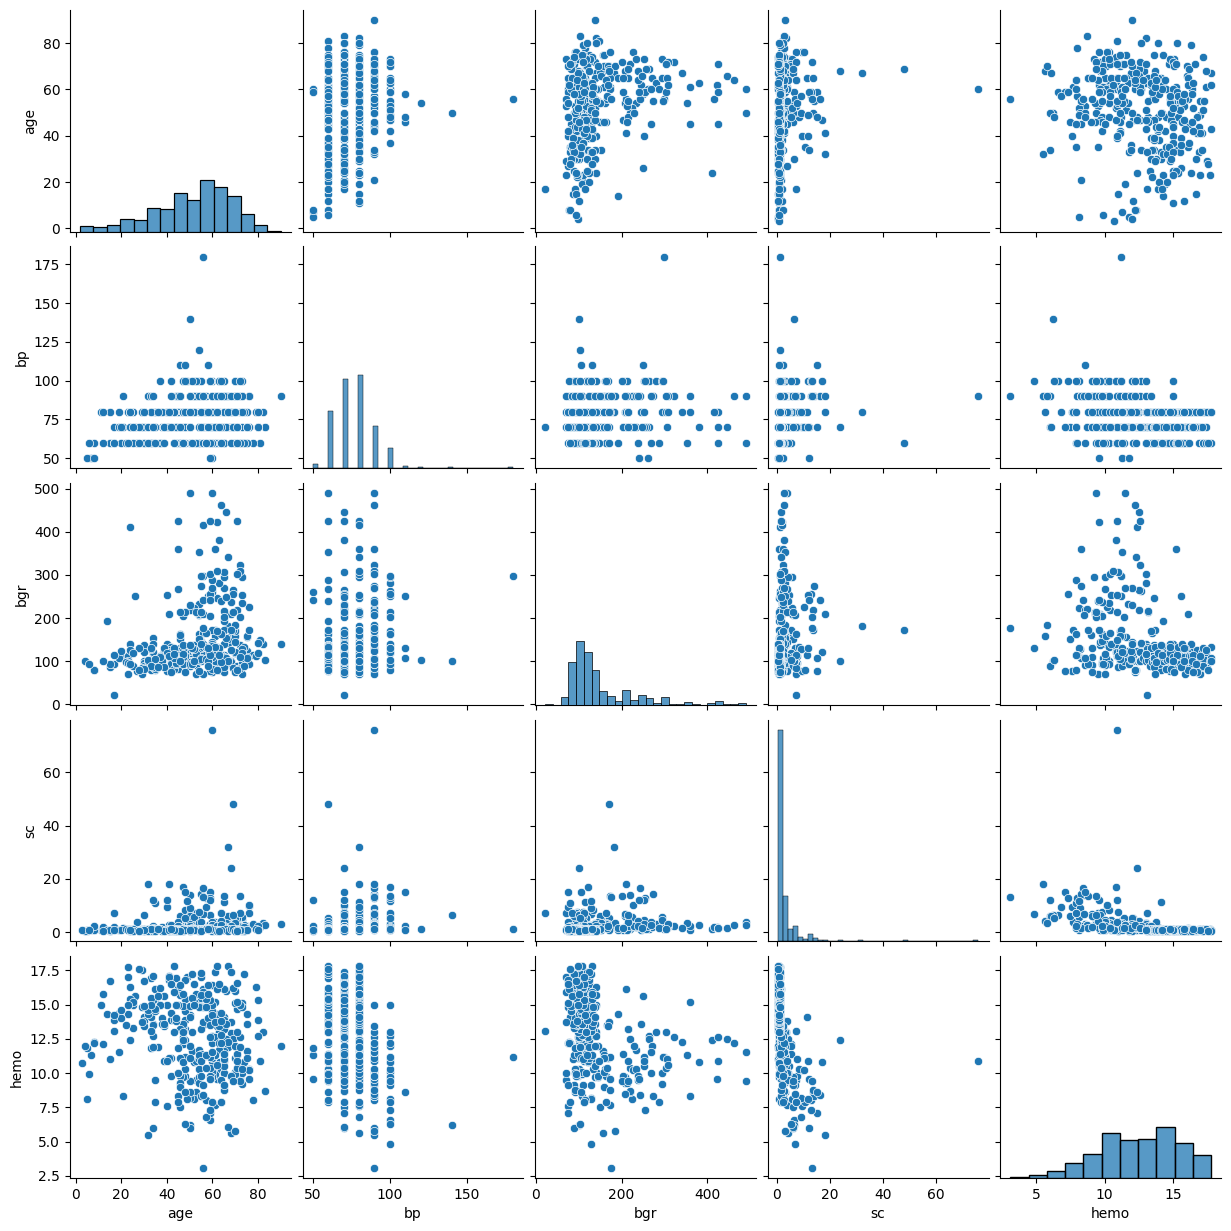

In [10]:
sns.pairplot(df[['age','bp','bgr','sc','hemo']])

For this analysis I explored relationships between several variables in the Chronic Kidney Disease dataset, including age, blood pressure, blood glucose, serum creatinine, and hemoglobin. The correlation matrix showed mostly weak to moderate relationships between these variables. The strongest relationship appeared to be a moderate negative correlation between serum creatinine and hemoglobin, which suggests that higher creatinine levels tend to occur alongside lower hemoglobin levels. The scatterplots support this pattern, although the relationship is not perfectly linear. I also noticed some clear outliers in variables such as blood glucose and serum creatinine where the values are much larger than most of the other observations. These extreme values may represent patients with more severe disease conditions. The pairplot also shows that many of the variables have a wide spread of values, which suggests that the dataset captures a diverse group of patients. Overall, the data appear realistic and usable for further analysis of chronic kidney disease risk factors. Possible confounding variables could include factors like diet, genetics, or lifestyle, which may influence kidney health but are not directly recorded in this dataset.

### Diabetes Health Indicators Dataset

In [11]:
df_diabetes = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

df_diabetes.info()
df_diabetes.describe()
df_diabetes.isnull().sum()
df_diabetes.duplicated().sum()
df_diabetes.nunique()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

Diabetes_012             3
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     84
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
dtype: int64

In [12]:
df_diabetes[['BMI','PhysHlth','MentHlth','GenHlth','Age']].corr()

,BMI,PhysHlth,MentHlth,GenHlth,Age
BMI,1.000000,0.121141,0.085310,0.239185,-0.036618
PhysHlth,0.121141,1.000000,0.353619,0.524364,0.099130
MentHlth,0.085310,0.353619,1.000000,0.301674,-0.092068
GenHlth,0.239185,0.524364,0.301674,1.000000,0.152450
Age,-0.036618,0.099130,-0.092068,0.152450,1.000000


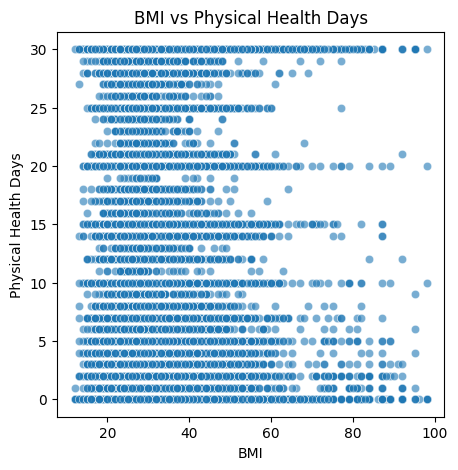

In [13]:
plt.figure(figsize=(5,5))

sns.scatterplot(data=df_diabetes, x="BMI", y="PhysHlth", alpha=0.6)

plt.title("BMI vs Physical Health Days")
plt.xlabel("BMI")
plt.ylabel("Physical Health Days")

plt.show()

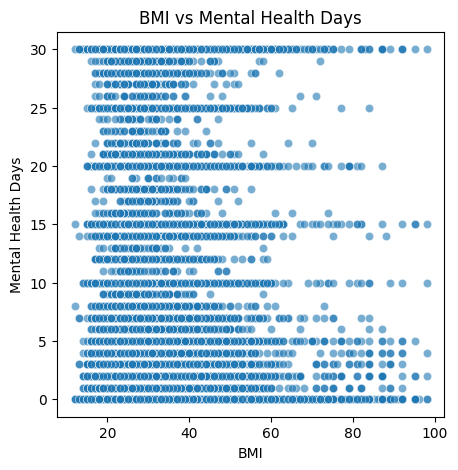

In [14]:
plt.figure(figsize=(5,5))

sns.scatterplot(data=df_diabetes, x="BMI", y="MentHlth", alpha=0.6)

plt.title("BMI vs Mental Health Days")
plt.xlabel("BMI")
plt.ylabel("Mental Health Days")

plt.show()

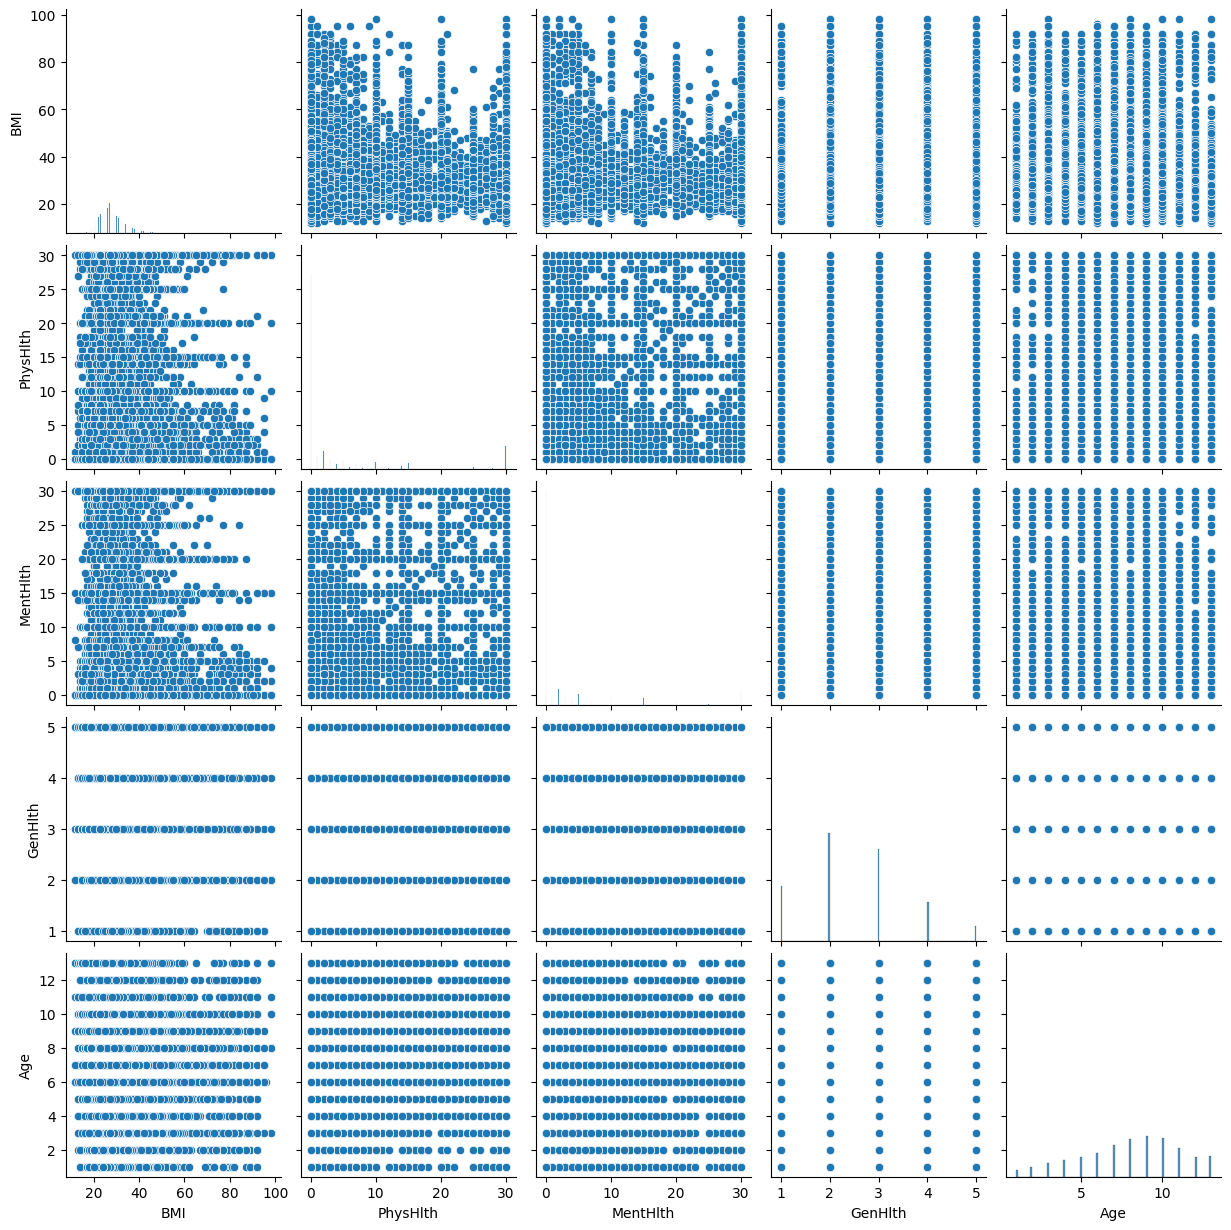

In [15]:
sns.pairplot(df_diabetes[['BMI','PhysHlth','MentHlth','GenHlth','Age']])

I also explored the diabetes health indicators dataset by examining relationships between BMI, physical health days, mental health days, general health, and age. The correlation matrix shows that most of the relationships between these variables are fairly weak, although there are some moderate correlations. The strongest relationship appears between physical health days and general health (R ≈ 0.52), which makes sense since individuals who report worse overall health tend to report more days of poor physical health. Mental health days also show a moderate relationship with physical health days (R ≈ 0.35), suggesting that physical and mental health issues may occur together. The scatterplots show a large amount of variation and clustering, particularly around zero days of poor health, which indicates that many individuals report no recent health problems. BMI appears to have only weak relationships with the other variables, suggesting that body mass index alone does not strongly predict reported health outcomes in this dataset. Overall, the data appear realistic and usable for studying health indicators related to diabetes risk, although potential confounding variables such as physical activity, diet, or socioeconomic status may also influence these health outcomes but are not fully captured in the dataset.

### Alzheimers Disease Dataset

In [16]:
df_alz = pd.read_csv("alzheimers_disease_data.csv")

df_alz.info()
df_alz.describe()
df_alz.isnull().sum()
df_alz.duplicated().sum()
df_alz.nunique()

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64  
 14  Dep

PatientID                    2149
Age                            31
Gender                          2
Ethnicity                       4
EducationLevel                  4
BMI                          2149
Smoking                         2
AlcoholConsumption           2149
PhysicalActivity             2149
DietQuality                  2149
SleepQuality                 2149
FamilyHistoryAlzheimers         2
CardiovascularDisease           2
Diabetes                        2
Depression                      2
HeadInjury                      2
Hypertension                    2
SystolicBP                     90
DiastolicBP                    60
CholesterolTotal             2149
CholesterolLDL               2149
CholesterolHDL               2149
CholesterolTriglycerides     2149
MMSE                         2149
FunctionalAssessment         2149
MemoryComplaints                2
BehavioralProblems              2
ADL                          2149
Confusion                       2
Disorientation

In [17]:
df_alz[['Age','BMI','PhysicalActivity','SleepQuality','CholesterolTotal','SystolicBP','Diagnosis']].corr()

,Age,BMI,PhysicalActivity,SleepQuality,CholesterolTotal,SystolicBP,Diagnosis
Age,1.000000,-0.015677,-0.010249,0.049139,0.000392,-0.005324,-0.005488
BMI,-0.015677,1.000000,0.000742,-0.005975,0.001082,-0.019275,0.026343
PhysicalActivity,-0.010249,0.000742,1.000000,-0.001823,0.014335,-0.004811,0.005945
SleepQuality,0.049139,-0.005975,-0.001823,1.000000,0.006879,-0.027887,-0.056548
CholesterolTotal,0.000392,0.001082,0.014335,0.006879,1.000000,0.018537,0.006394
SystolicBP,-0.005324,-0.019275,-0.004811,-0.027887,0.018537,1.000000,-0.015615
Diagnosis,-0.005488,0.026343,0.005945,-0.056548,0.006394,-0.015615,1.000000


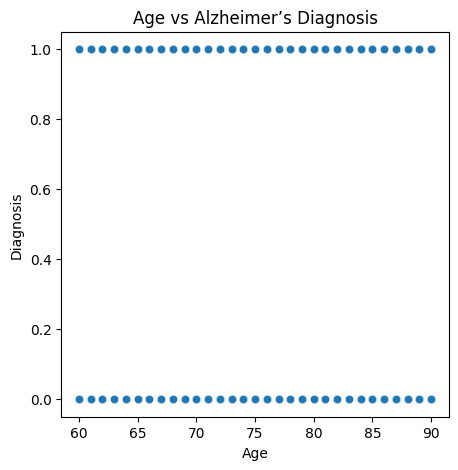

In [18]:
plt.figure(figsize=(5,5))

sns.scatterplot(data=df_alz, x="Age", y="Diagnosis", alpha=0.6)

plt.title("Age vs Alzheimer’s Diagnosis")
plt.xlabel("Age")
plt.ylabel("Diagnosis")

plt.show()

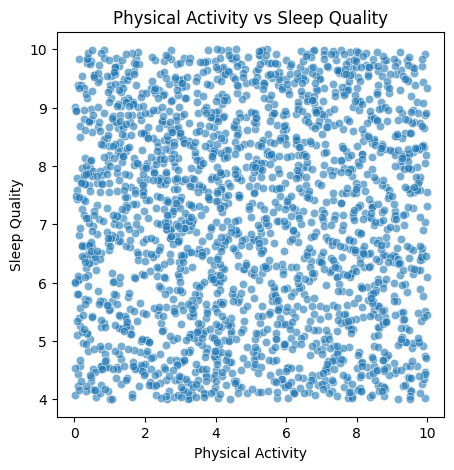

In [19]:
plt.figure(figsize=(5,5))

sns.scatterplot(data=df_alz, x="PhysicalActivity", y="SleepQuality", alpha=0.6)

plt.title("Physical Activity vs Sleep Quality")
plt.xlabel("Physical Activity")
plt.ylabel("Sleep Quality")

plt.show()

KeyboardInterrupt: 

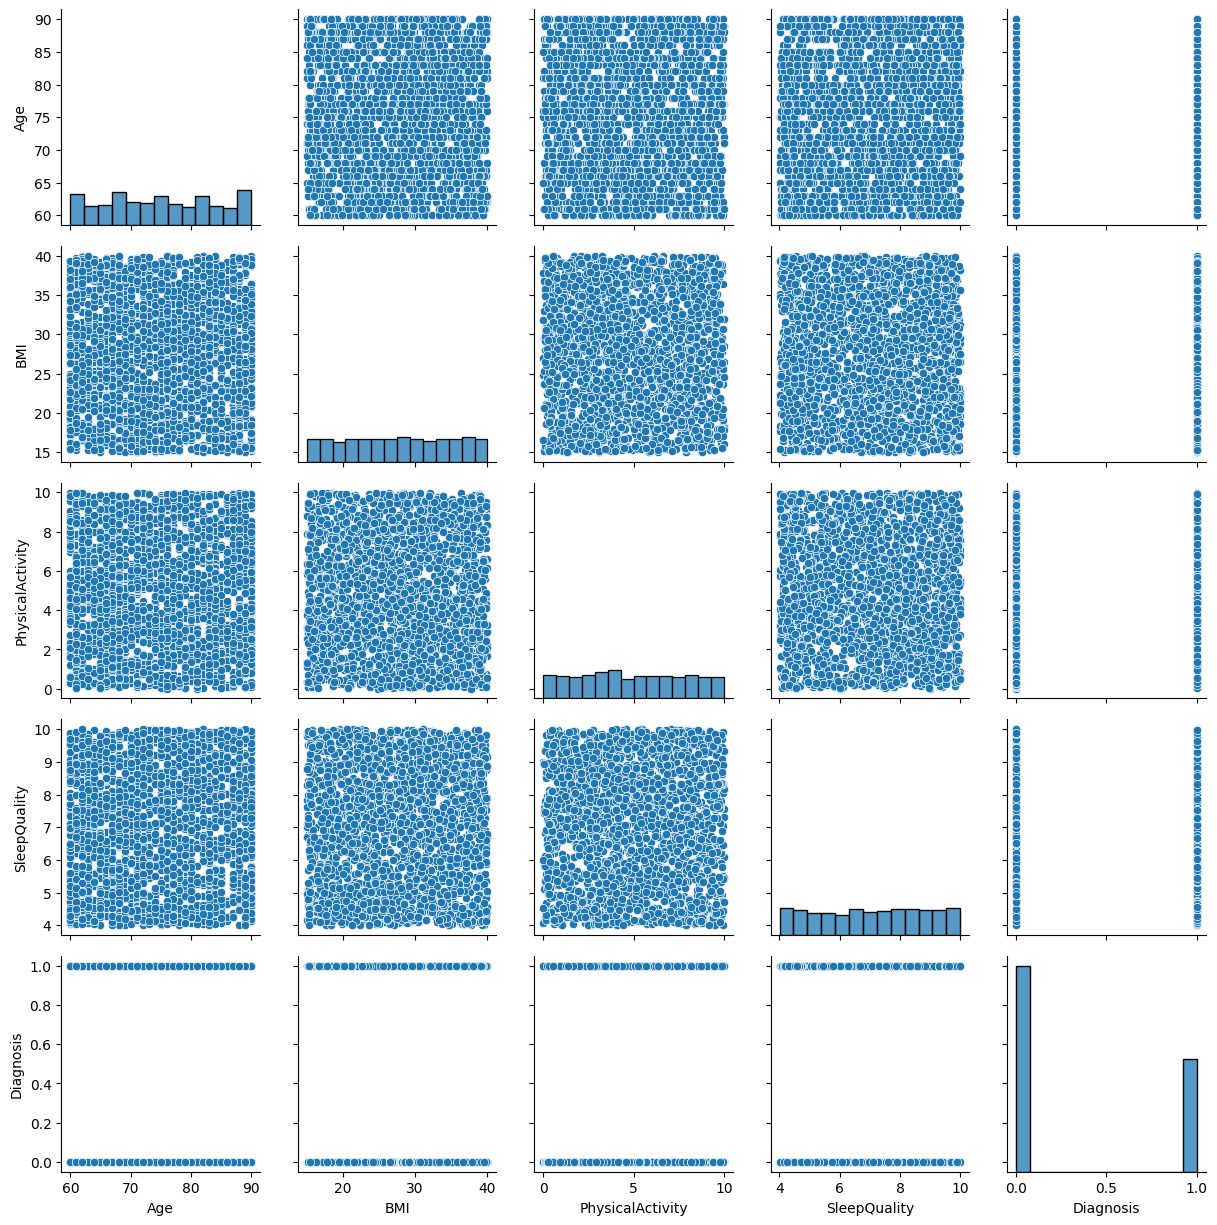

In [20]:
sns.pairplot(df_alz[['Age','BMI','PhysicalActivity','SleepQuality','Diagnosis']])

I also explored the Alzheimer’s disease dataset by examining relationships between variables such as age, BMI, physical activity, sleep quality, cholesterol levels, and diagnosis. The correlation matrix shows that most of the relationships between these variables are extremely weak, with correlation values very close to zero. This suggests that none of the individual variables have a strong linear relationship with the Alzheimer’s diagnosis variable in this dataset. The scatterplots also show no clear patterns, with points spread widely across the graphs. In particular, the Age vs Diagnosis plot shows that individuals with and without Alzheimer’s appear across the entire age range, which explains why the correlation between age and diagnosis is very small. The pairplot further confirms that the variables have large variability but do not show strong linear relationships with one another. Many of the variables are discrete scales, which creates grid-like patterns in the scatterplots rather than continuous distributions. Overall, the dataset appears realistic and usable for exploratory analysis, but it also highlights that Alzheimer’s disease is likely influenced by multiple biological, genetic, and environmental factors rather than a single measurable variable. Possible confounding variables could include genetic predisposition, long-term health conditions, or environmental influences that are not fully captured in this dataset.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

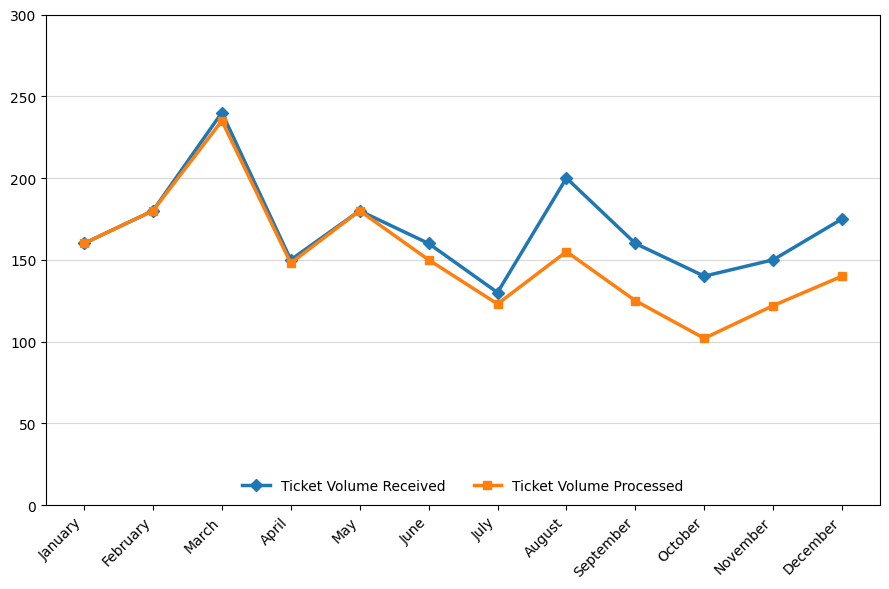

In [ ]:
import matplotlib.pyplot as plt

months = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

ticket_received = [160, 180, 240, 150, 180, 160, 130, 200, 160, 140, 150, 175]
ticket_processed = [160, 180, 235, 148, 180, 150, 123, 155, 125, 102, 122, 140]

plt.figure(figsize=(9,6))

plt.plot(
    months, ticket_received,
    marker='D',
    linewidth=2.5,
    label='Ticket Volume Received'
)

plt.plot(
    months, ticket_processed,
    marker='s',
    linewidth=2.5,
    label='Ticket Volume Processed'
)

plt.ylim(0, 300)
plt.ylabel("")
plt.title("")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='-', alpha=0.5)
plt.legend(loc='lower center', ncol=2, frameon=False)

plt.tight_layout()
plt.show()

I chose to reproduce Figure 3.17

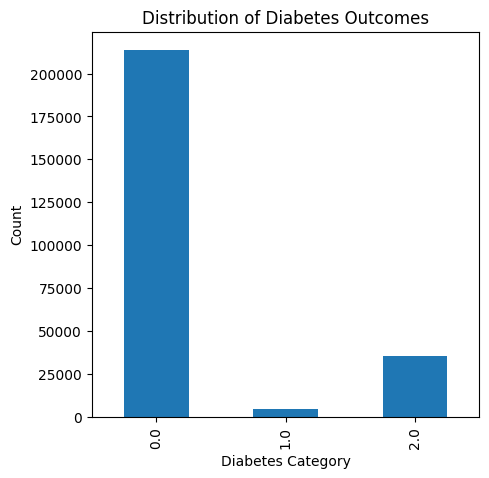

In [ ]:
plt.figure(figsize=(5,5))
df_diabetes['Diabetes_012'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Diabetes Outcomes")
plt.xlabel("Diabetes Category")
plt.ylabel("Count")
plt.show()

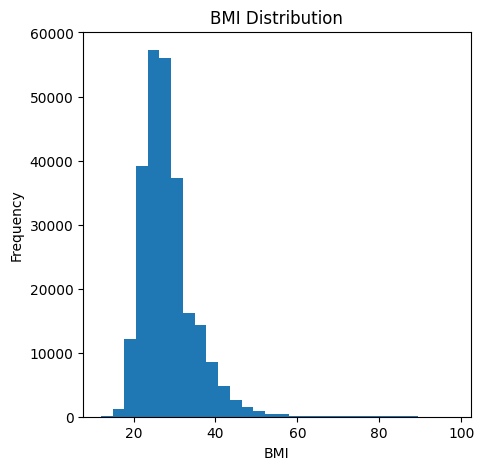

In [ ]:
plt.figure(figsize=(5,5))
plt.hist(df_diabetes['BMI'], bins=30)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

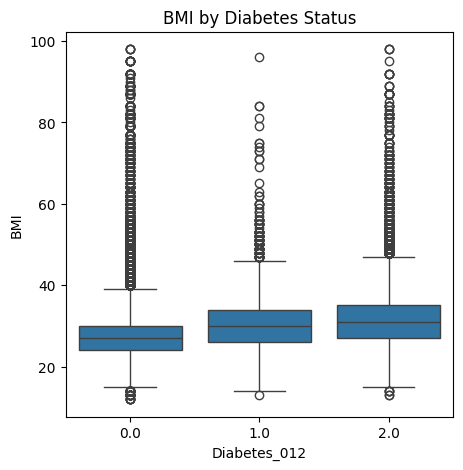

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(x='Diabetes_012', y='BMI', data=df_diabetes)
plt.title("BMI by Diabetes Status")
plt.show()

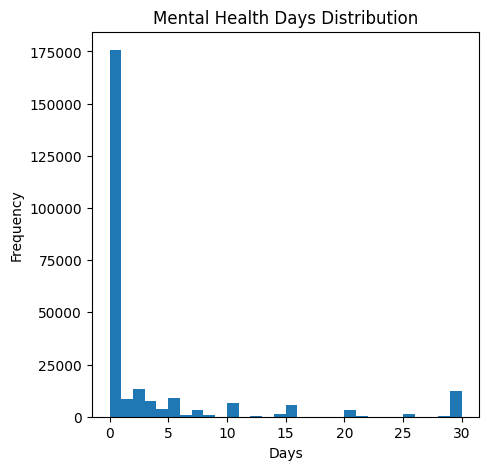

In [ ]:
plt.figure(figsize=(5,5))
plt.hist(df_diabetes['MentHlth'], bins=30)
plt.title("Mental Health Days Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

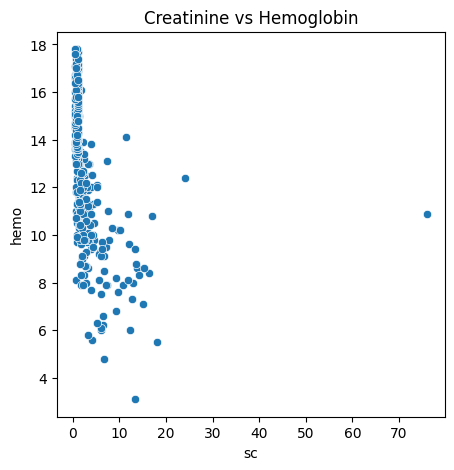

In [ ]:
plt.figure(figsize=(5,5))
sns.scatterplot(x='sc', y='hemo', data=df)
plt.title("Creatinine vs Hemoglobin")
plt.show()

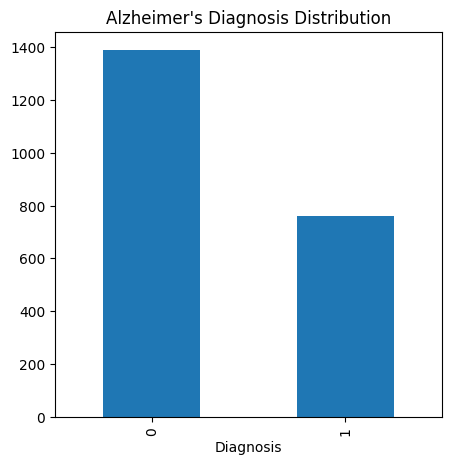

In [ ]:
plt.figure(figsize=(5,5))
df_alz['Diagnosis'].value_counts().plot(kind='bar')
plt.title("Alzheimer's Diagnosis Distribution")
plt.show()

In [ ]:
df_diabetes[['BMI','MentHlth','PhysHlth','GenHlth']].describe()

,BMI,MentHlth,PhysHlth,GenHlth
count,253680.000000,253680.000000,253680.000000,253680.000000
mean,28.382364,3.184772,4.242081,2.511392
std,6.608694,7.412847,8.717951,1.068477
min,12.000000,0.000000,0.000000,1.000000
25%,24.000000,0.000000,0.000000,2.000000
50%,27.000000,0.000000,0.000000,2.000000
75%,31.000000,2.000000,3.000000,3.000000
max,98.000000,30.000000,30.000000,5.000000


In [ ]:
df_diabetes['Diabetes_012'].value_counts()

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

In [ ]:
df[['sc','hemo','bgr','bu']].describe()

,sc,hemo,bgr,bu
count,383.000000,348.000000,356.000000,381.000000
mean,3.072454,12.526437,148.036517,57.425722
std,5.741126,2.912587,79.281714,50.503006
min,0.400000,3.100000,22.000000,1.500000
25%,0.900000,10.300000,99.000000,27.000000
50%,1.300000,12.650000,121.000000,42.000000
75%,2.800000,15.000000,163.000000,66.000000
max,76.000000,17.800000,490.000000,391.000000


In [ ]:
df_alz[['Age','BMI','SystolicBP','DiastolicBP']].describe()

,Age,BMI,SystolicBP,DiastolicBP
count,2149.000000,2149.000000,2149.000000,2149.000000
mean,74.908795,27.655697,134.264774,89.847836
std,8.990221,7.217438,25.949352,17.592496
min,60.000000,15.008851,90.000000,60.000000
25%,67.000000,21.611408,112.000000,74.000000
50%,75.000000,27.823924,134.000000,91.000000
75%,83.000000,33.869778,157.000000,105.000000
max,90.000000,39.992767,179.000000,119.000000


In [ ]:
df_alz['Diagnosis'].value_counts()

Diagnosis
0    1389
1     760
Name: count, dtype: int64

In [ ]:
df_diabetes[['BMI','MentHlth']].skew()

BMI         2.122004
MentHlth    2.721148
dtype: float64

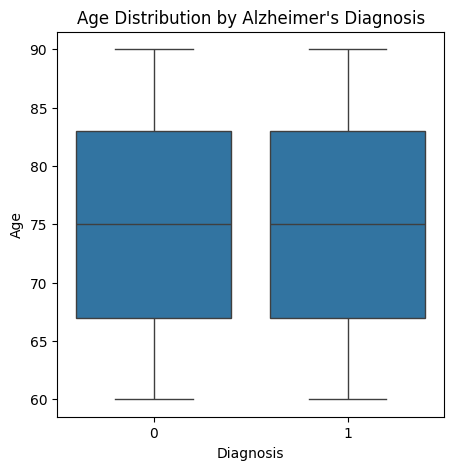

In [21]:
plt.figure(figsize=(5,5))
sns.boxplot(x='Diagnosis', y='Age', data=df_alz)
plt.title("Age Distribution by Alzheimer's Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Age")
plt.show()

In [22]:
df_alz.groupby("Diagnosis")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Diagnosis,,,,,,,,
0,1389.0,74.945284,8.904709,60.0,67.0,75.0,83.0,90.0
1,760.0,74.842105,9.149977,60.0,67.0,75.0,83.0,90.0
